In [403]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


In [404]:
df = pd.read_csv('/users/imbahndu/Desktop/Columbia DBM/Typing dataset/typing.csv', low_memory=False)

In [405]:
df.head()

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False


In [406]:
#Finding out the number of missing values
null_series = df.isnull().sum()

print(null_series)

print(type(null_series))

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        2153339
Gender            301987
Parkinsons        301987
Tremors           301987
DiagnosisYear    1469539
Sided            3498254
UPDRS             301987
Impact            480998
Levadopa          301987
DA                301987
MAOB              301987
Other             301987
dtype: int64
<class 'pandas.core.series.Series'>


In [407]:
#Dropping all the rows with couts 301987
rows_to_drop = []
for col in range(len(null_series)):
    if null_series[col] == 301987:
        rows_to_drop.append(col)

columns = [] 
for row in rows_to_drop:
    columns.append(df.columns[row])

print(columns)

df = df.dropna(subset = columns)
print(df)

['Gender', 'Parkinsons', 'Tremors', 'UPDRS', 'Levadopa', 'DA', 'MAOB', 'Other']


/tmp/ipykernel_3283435/2088116909.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if null_series[col] == 301987:


         Unnamed: 0     UserKey    Date     Timestamp Hand HoldTime Direction  \
0                 0  0EA27ICBLF  160722  18:41:04.336    L   0101.6        LL   
1                 1  0EA27ICBLF  160722  18:42:14.070    L   0085.9        LL   
2                 2  0EA27ICBLF  160722  18:42:14.273    L   0078.1        LL   
3                 3  0EA27ICBLF  160722  18:42:14.617    L   0062.5        LL   
4                 4  0EA27ICBLF  160722  18:42:15.586    S   0125.0        LS   
...             ...         ...     ...           ...  ...      ...       ...   
9316853     9316853  ZYWLN4JVLA  170126  13:56:20.117    L   0195.3        RL   
9316854     9316854  ZYWLN4JVLA  170126  13:56:20.242    R   0105.5        LR   
9316855     9316855  ZYWLN4JVLA  170126  13:56:33.625    L   0168.0        LL   
9316856     9316856  ZYWLN4JVLA  170126  13:56:33.836    L   0097.7        LL   
9316857     9316857  ZYWLN4JVLA  170126  13:56:34.066    L   0168.0        LL   

        LatencyTime FlightT

In [408]:
#Verifying if code worked and all rows with 301987
df.isnull().sum()

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        1851352
Gender                 0
Parkinsons             0
Tremors                0
DiagnosisYear    1167552
Sided            3196267
UPDRS                  0
Impact            179011
Levadopa               0
DA                     0
MAOB                   0
Other                  0
dtype: int64

In [409]:
#Dropping the unnamed column --> don't see why it's necessary
df.drop(columns = "Unnamed: 0")

,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [410]:
df["Parkinsons"].value_counts()

#Will balance this during preprocessing 

Parkinsons
True     6470722
False    2544149
Name: count, dtype: int64

In [411]:
#Checking the URPDS column
df["UPDRS"].value_counts()

UPDRS
Don't know    8203052
4              717717
3               68171
2               25922
1                   9
Name: count, dtype: int64

In [412]:
#Dropping columns (both categorical and numerical col) that will not impact a model
df = df.drop(columns = ["BirthYear", "UserKey", "Tremors", "DiagnosisYear", "Sided", "Impact", "UPDRS", "Levadopa", "MAOB", "DA", "Other", "Unnamed: 0", "Date", "Filename", "Timestamp"])


In [413]:
#One hot enconding teh gender
df = pd.get_dummies(df, columns=["Gender"],drop_first=True)

In [414]:
df.head(10)

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,False
1,L,0085.9,LL,0437.5,0359.4,True,False
2,L,0078.1,LL,0210.9,0125.0,True,False
3,L,0062.5,LL,0359.4,0281.3,True,False
4,S,0125.0,LS,0187.5,0093.8,True,False
5,L,0078.1,SL,0226.6,0101.6,True,False
6,R,0085.9,LR,0195.3,0117.2,True,False
7,R,0085.9,RR,0359.4,0296.9,True,False
8,L,0070.3,RL,0429.7,0343.8,True,False
9,L,0101.6,LL,0406.3,0335.9,True,False


In [415]:
print(df["Hand"].unique())

['L' 'S' 'R' '160725' '160809' '160813' '23:17:06.555' '170221' '170228'
 '14:01:21.672' '3MZWDTW7CC' '08:40:34.025' '17:38:13.930' '5ARV4LHEJ0'
 '16:17:54.109' '02:20:42.267' '170203' '20:40:00.594' '19:49:06.688'
 '161001' 'L8EY6NZAKCI' '170201' 'R95S93AXF86' '170212' '170215' '170218'
 '170220' '170222' '170223' '170226' '95S93AXF86' '170302' '170209'
 '160814' '160817' '14:07:18.391' '160820' '160822' '160823' '160824'
 '160826' '160827' '160829' '160830' '160831' 'AFNOZ1KI1M' '160904'
 '160905' '11:22:30.074' '160921' '160924' '160925' '160926'
 '07:20:50.789' '10:02:07.637' '161128' 'LAFQWSP8ARK' '160726' '160912'
 '12:01:03.844' '170107' '170115' '15:38:02.125' '11:25:55.363' '161010'
 '170103' '170217' '170225' '161223' '161116' '20:44:51.438' 'FXC5YFXZ0K'
 '170120' '11:37:59.215' '170207' '17:12:53.633' '160805' '160812'
 '160901' '07:54:11.604' '160908' '160911' '11:46:48.309' '160923'
 '170211' '170126' '23:52:20.352' '160808' '10:28:47.816' '160816'
 '08:26:14.389' '07:43:4

In [416]:
print(df["Direction"].unique())

['LL' 'LS' 'SL' 'LR' 'RR' 'RL' 'RS' 'SR' 'SS' '160725' 'L' 'L0EA27ICBLF'
 'S' '0156.3' '170225' '0253.9' '09:21:16.109' '0171.9' '0187.5'
 '09:15:01.008' 'RR3MZWDTW7CC' '160929' '12:20:50.980' '0121.1' '0139.6'
 'LL6WBXSDG5BB' 'L6WBXSDG5BB' '170203' '81NEUZEBXI' '0218.8' 'R'
 '05:15:55.525' '170213' '95S93AXF86' '10:59:11.953' '170224'
 '14:16:13.559' 'AFNOZ1KI1M' '160818' '0128.9' '160825' '160827'
 'SRAFNOZ1KI1M' 'RAFNOZ1KI1M' '15:32:50.891' '160903' '160919' '0146.5'
 '0191.4' '09:50:19.398' '0125.0' '0031.3' '0105.5' '170121' '160811'
 '161007' 'FHEOPKL3QQ' '161028' '0140.6' '11:48:00.484' '161125' '0101.6'
 '160809' '0080.1' '0074.2' '160802' '160806' '160815' '0056.6' '0160.2'
 '160908' '0085.9' '14:14:07.031' 'LLJMIVIRFQRR' '160726' '160727'
 '0001.0' '0127.9' 'LJMIVIRFQRR' '160823' '160828' 'JMIVIRFQRR'
 '21:44:15.812' '0078.1' '07:53:31.539' 'RRJMIVIRFQRR' '0070.3' '0104.0'
 '16:15:37.516' 'LLJMYZ5IKGWE' '0113.3' 'KTUVFFSLN4' '160821'
 '18:12:51.539' '161127' '0210.9' '161118'

In [417]:
#Dropping rows with weird labels for categorical and numerical columns
correct_hands = ["L", "R"]

for col in correct_hands:

    df = df[df["Hand"].isin(correct_hands)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,False
1,L,0085.9,LL,0437.5,0359.4,True,False
2,L,0078.1,LL,0210.9,0125.0,True,False
3,L,0062.5,LL,0359.4,0281.3,True,False
5,L,0078.1,SL,0226.6,0101.6,True,False
...,...,...,...,...,...,...,...
9316853,L,0195.3,RL,0425.8,261.7,True,False
9316854,R,0105.5,LR,0214.8,19.5,True,False
9316855,L,0168.0,LL,0332.0,15.6,True,False
9316856,L,0097.7,LL,0281.3,113.3,True,False


In [418]:
#Verifying if I got rid of all weird  numbers
print(df["Hand"].value_counts())

print(df["Hand"].unique())

Hand
L    4245766
R    3198166
Name: count, dtype: int64
['L' 'R']


In [419]:
#Doing thesame thing for direction 

correct_directions = ["LL","LR" ,"RR", "RL"]

for col in correct_directions:

    df = df[df["Direction"].isin(correct_directions)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,False
1,L,0085.9,LL,0437.5,0359.4,True,False
2,L,0078.1,LL,0210.9,0125.0,True,False
3,L,0062.5,LL,0359.4,0281.3,True,False
6,R,0085.9,LR,0195.3,0117.2,True,False
...,...,...,...,...,...,...,...
9316853,L,0195.3,RL,0425.8,261.7,True,False
9316854,R,0105.5,LR,0214.8,19.5,True,False
9316855,L,0168.0,LL,0332.0,15.6,True,False
9316856,L,0097.7,LL,0281.3,113.3,True,False


 LightBGM modeling-specific Label Encoding Categorical Variables 

In [420]:
#LabelEncoding these values --> For future app, this would be helpful

cat_columns = ["Hand", "Direction"]

from sklearn.preprocessing import LabelEncoder

#Calling the module, fitting for each cat variables

for col in df[cat_columns]:

    label_encoder = LabelEncoder()

    df[col] = label_encoder.fit_transform(df[col])
    
    print(df[col].unique())


[0 1]
[0 1 3 2]


In [421]:
print(df["Hand"].unique())

[0 1]


In [422]:
print(df["Direction"])

0          0
1          0
2          0
3          0
6          1
          ..
9316853    2
9316854    1
9316855    0
9316856    0
9316857    0
Name: Direction, Length: 6237183, dtype: int64


In [423]:
#Printing the types of all columns
print(df.dtypes)


Hand            int64
HoldTime       object
Direction       int64
LatencyTime    object
FlightTime     object
Parkinsons     object
Gender_Male      bool
dtype: object


In [424]:
#Drooping the expected numerical columns to float
expected_numerical = ["HoldTime", "LatencyTime", "FlightTime"]

# Convert columns to numeric, else convert them to NAN
for col in expected_numerical:

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in any of the expected numeric columns
df.dropna(subset=expected_numerical, inplace=True)


In [425]:
#Converting the string literal of PD to bool 

df["Parkinsons"] = df["Parkinsons"].astype(bool)

In [426]:
print(df.dtypes)

Hand             int64
HoldTime       float64
Direction        int64
LatencyTime    float64
FlightTime     float64
Parkinsons        bool
Gender_Male       bool
dtype: object


In [427]:
#Saving df at this stage as for lightbgm

df.to_csv("lightbgm.csv",  index=True)

In [428]:
#One hot encoding catgorical variables

cat_columns =[col for col in df.columns if df[col].dtype == "object"]

#Saving numerical columns just in case
num_columns = [col for col in df.columns if df[col].dtype == "float64" or df[col].dtype == "int64"]

df = pd.get_dummies(df, columns=cat_columns, dtype=float)

In [429]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,101.6,0,234.4,156.3,True,False
1,0,85.9,0,437.5,359.4,True,False
2,0,78.1,0,210.9,125.0,True,False
3,0,62.5,0,359.4,281.3,True,False
6,1,85.9,1,195.3,117.2,True,False
...,...,...,...,...,...,...,...
9316853,0,195.3,2,425.8,261.7,True,False
9316854,1,105.5,1,214.8,19.5,True,False
9316855,0,168.0,0,332.0,15.6,True,False
9316856,0,97.7,0,281.3,113.3,True,False


In [430]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [431]:
#Scaling the numerical columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[num_columns])

data_scaled = scaler.fit_transform(df[num_columns])

print(scaler.mean_)

[  0.4413121   56.30004966   1.35647195 259.34809374 186.23972916]


In [432]:
#Keeping the preprocessed file another csv to facilate modeling

df.to_csv("modeling.csv", index=False)

In [433]:
#Visualizations 

import numpy as np


In [434]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,101.6,0,234.4,156.3,True,False
1,0,85.9,0,437.5,359.4,True,False
2,0,78.1,0,210.9,125.0,True,False
3,0,62.5,0,359.4,281.3,True,False
6,1,85.9,1,195.3,117.2,True,False
...,...,...,...,...,...,...,...
9316853,0,195.3,2,425.8,261.7,True,False
9316854,1,105.5,1,214.8,19.5,True,False
9316855,0,168.0,0,332.0,15.6,True,False
9316856,0,97.7,0,281.3,113.3,True,False


In [435]:
#Making sure everything is consistent one more time 

for col in df.columns:

    print(col)

    print()

    print(df[col].unique())


Hand

[0 1]
HoldTime

[101.6  85.9  78.1 ...   3.4   2.1   3.2]
Direction

[0 1 3 2]
LatencyTime

[234.4 437.5 210.9 ...  54.1  13.2 459.5]
FlightTime



[156.3 359.4 125.  ... 386.1 672.4 165.5]
Parkinsons

[ True False]
Gender_Male

[False  True]


In [436]:
#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

Pairplot Visualizations

In [437]:
plt_columns = ["HoldTime", "LatencyTime", "FlightTime", "Parkinsons"]
#sns.pairplot(df[plt_columns], hue="Parkinsons", diag_kind="kde")
#plt.show()

Heatmap Correlations

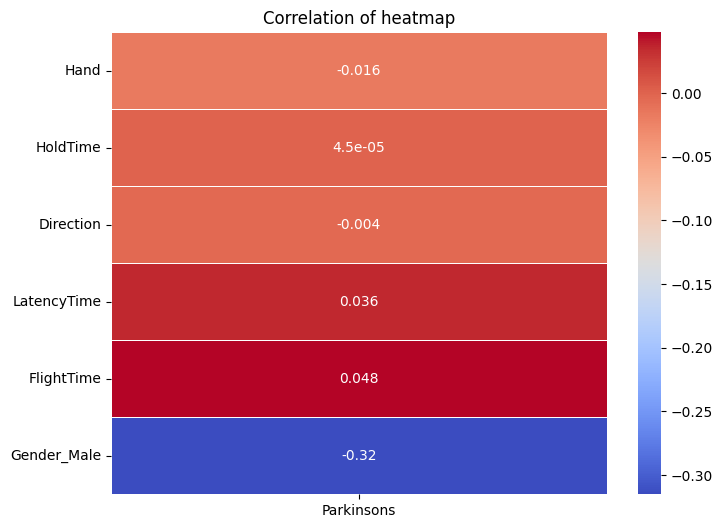

In [438]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


Histograms plotting for each feature

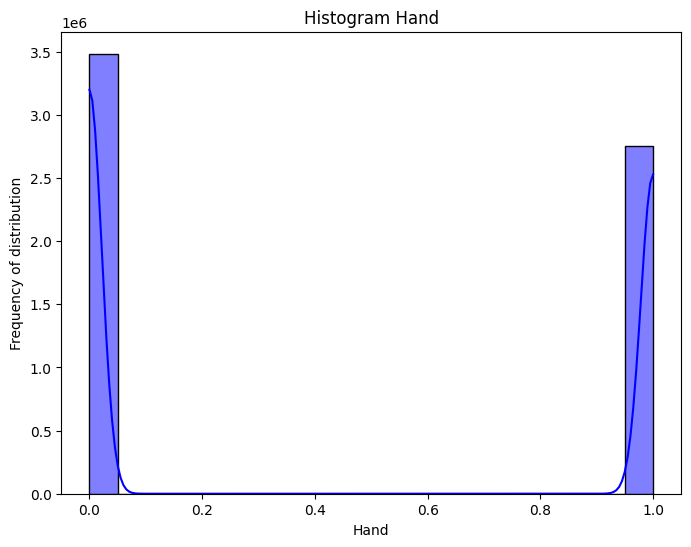

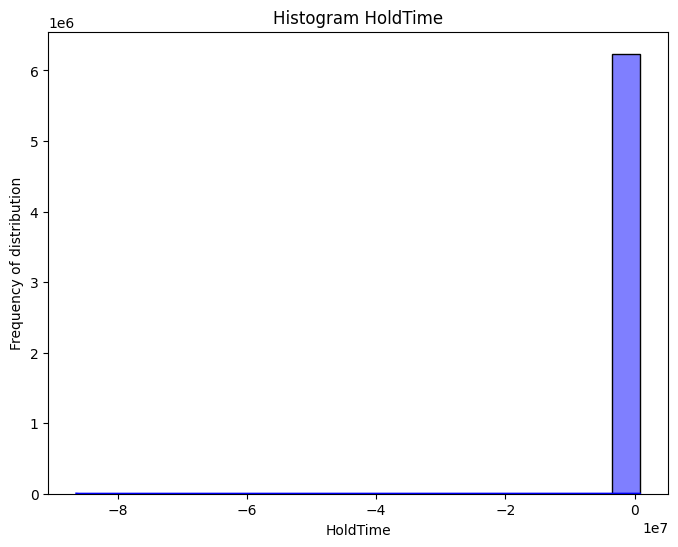

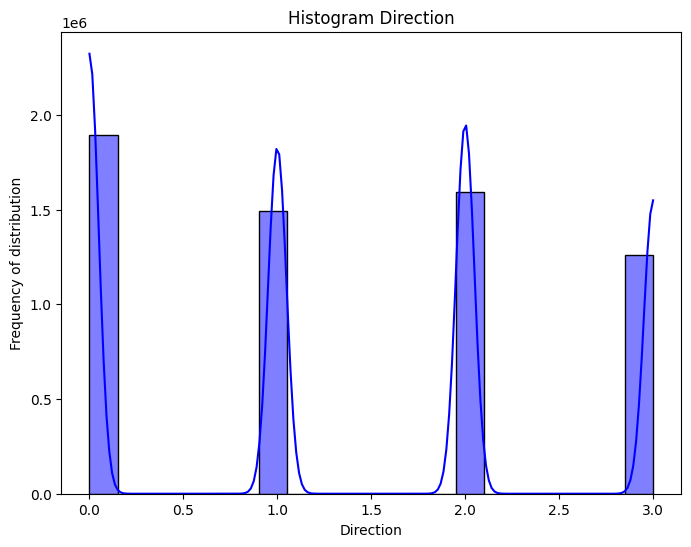

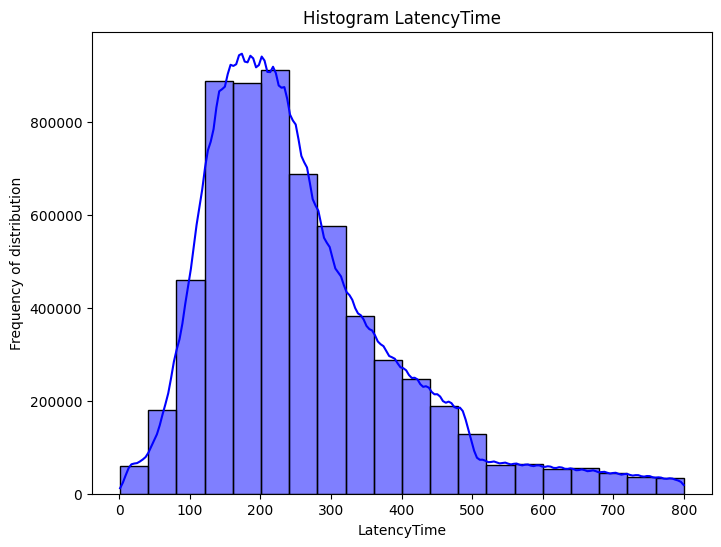

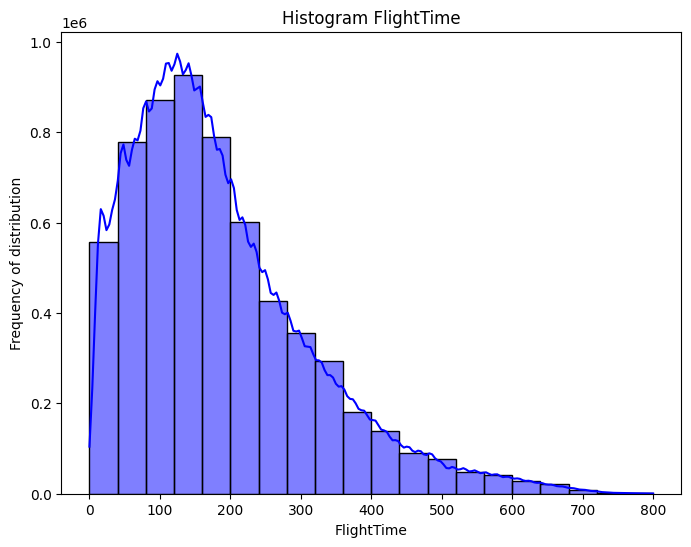

In [439]:
#Looping over num_columns for histogram plot
for col in num_columns:
    
    plt.figure(figsize=(8,6))
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title("Histogram" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Visualizations after preprocessing 

In [440]:
#Creating a dataframe with the scaled data and visualizing it again 
df_scaled = pd.DataFrame(data=data_scaled, columns=num_columns)

df_scaled

,Hand,HoldTime,Direction,LatencyTime,FlightTime
0,-0.888768,0.000655,-1.217720,-0.177385,-0.231772
1,-0.888768,0.000428,-1.217720,1.266691,1.340485
2,-0.888768,0.000315,-1.217720,-0.344474,-0.474075
3,-0.888768,0.000090,-1.217720,0.711386,0.735890
4,1.125153,0.000428,-0.320009,-0.455393,-0.534457
...,...,...,...,...,...
6236971,-0.888768,0.002009,0.577702,1.183502,0.584160
6236972,1.125153,0.000711,-0.320009,-0.316745,-1.290782
6236973,-0.888768,0.001614,-1.217720,0.516568,-1.320973
6236974,-0.888768,0.000598,-1.217720,0.156082,-0.564648


Histogram visualizations

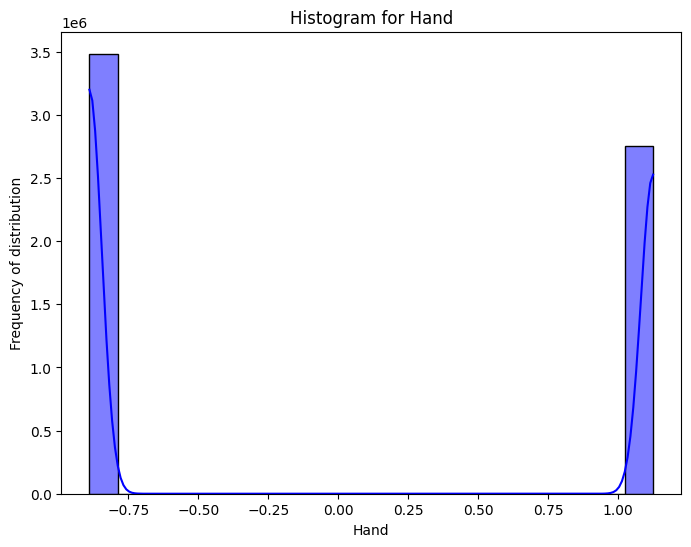

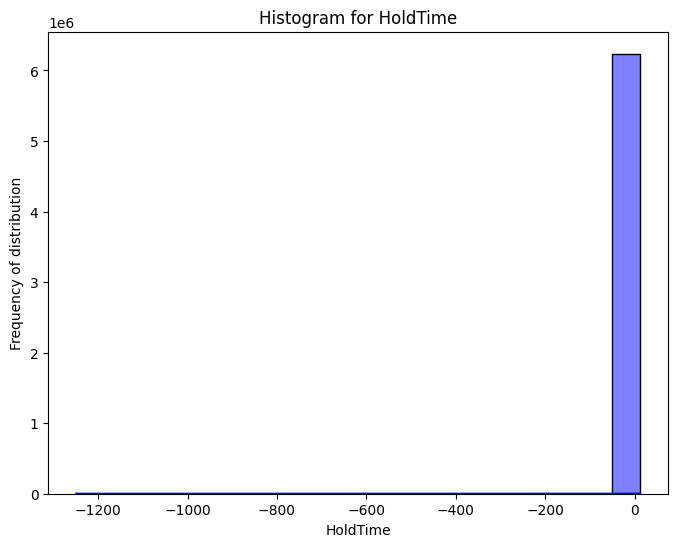

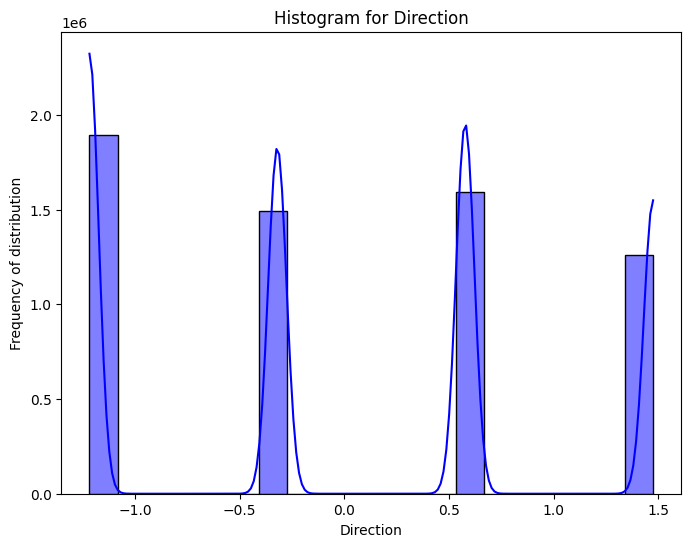

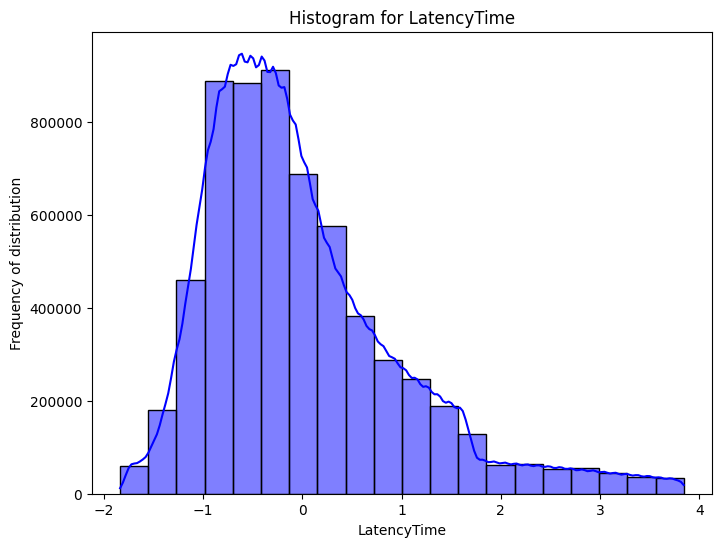

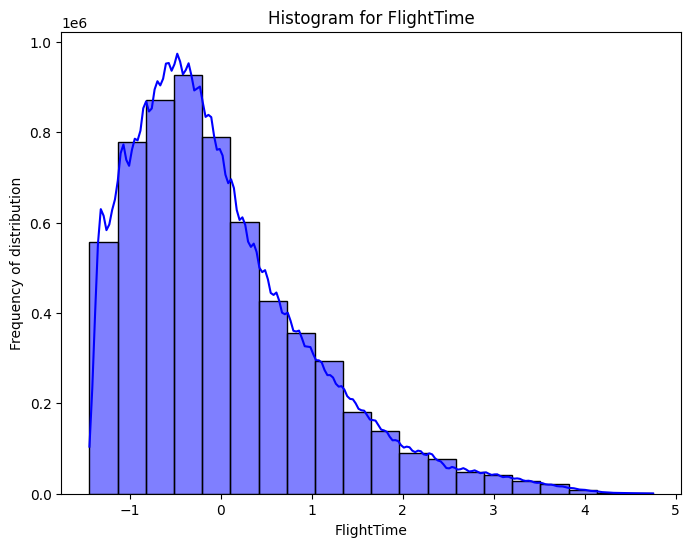

In [441]:
for col in num_columns:
    
    plt.figure(figsize=(8,6))
    sns.histplot(df_scaled[col], bins=20, kde=True, color="blue")
    plt.title("Histogram for" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Pairplot visualizations

In [442]:
#sns.pairplot(df_scaled[plt_columns], hue="Parkinsons", diag_kind="kde")
#plt.show()

Heatmap Visualizations

In [443]:
df_scaled["Parkinsons"] = df["Parkinsons"]

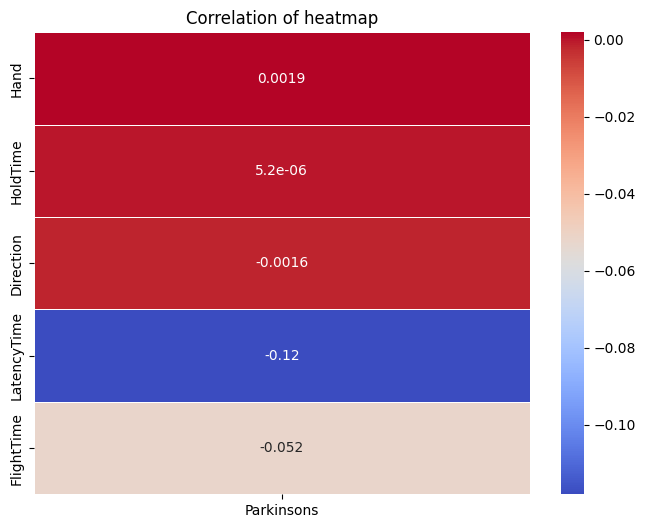

In [444]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()
